# MDTF Example Diagnostic POD for Multiple Cases / Experiments
### Uses: Data catalogs
### Disclaimer: Debug mode with some hardcoded values will be found in this notebook. MDTF integration is underway. This is essentially to see how things may flow from the user configuration files to the MDTF framework and into the POD, including figure generation. 

In [1]:
# ================================================================================
#
# This file is part of the Multicase Example Diagnostic POD of the MDTF code
# package (see mdtf/MDTF-diagnostics/LICENSE.txt)
#
# Example Diagnostic POD
#
#   Last update: March 2024 (exploring intake-esm catalog in the MDTF framework and the POD)
#
#   This example builds upon the single case `example` POD
#   and illustrates how to design and implement a POD that uses multiple
#   model source datasets. These can be the same experiment with different
#   models, two different experiments from the same model, or two different
#   time periods within the same simulation.
#
#   Version & Contact info
#
#   - Version/revision information: version 1.1 (Oct-2022)
#   - Model Development Task Force Framework Team
#
#   Open source copyright agreement
#
#   The MDTF framework is distributed under the LGPLv3 license (see LICENSE.txt).
#
#   Functionality
#
#   Metadata associated with the different cases are passed from the
#   framework to the POD via a yaml file (case_info.yaml) that the POD reads into a dictionary.
#   The POD iterates over the case entries in the dictionary and opens the input datasets.
#   The `tas` variable is extracted for each case and the time average is taken over the dataset.
#   Anomalies are calculated relative to the global mean and then zonally-averaged. The resulting plot
#   contains one line for each case.
#
#   Required programming language and libraries
#
#     * Python >= 3.10
#     * xarray
#     * matplotlib
#     * intake
#     * yaml
#     * sys
#     * os
#     * numpy
#
#   Required model output variables
#
#     * tas - Surface (2-m) air temperature (CF: air_temperature)
#
#   References
#
#      Maloney, E. D, and Co-authors, 2019: Process-oriented evaluation of climate
#         and wether forcasting models. BAMS, 100(9), 1665-1686,
#         doi:10.1175/BAMS-D-18-0042.1.

## Import necessary packages

In [2]:
# Import modules used in the POD
import os
import matplotlib

matplotlib.use("Agg")  # non-X windows backend

import matplotlib.pyplot as plt
%matplotlib inline 
import numpy as np
import intake
import sys
import yaml
import warnings

warnings.filterwarnings("ignore")

NOTE: We are exploring..so..there will be some hardcoded paths here, which MDTF framework
will help us remove when the feature is available in the framework.

## Part 1: Read in case info (in the format (YAML) that MDTF generates for the run)

In [3]:
# Debugging: remove following line in final PR
os.environ["REPO_ROOT"] = "/work/Janice.Kim/mdtf_main/MDTF-diagnostics"
os.environ["WORK_DIR"] = "/work/Janice.Kim/mdtf_main/wkdir"
#os.environ["case_env_file"] = "/work/Janice.Kim/mdtf_main/MDTF-diagnostics/diagnostics/example_multicase/case_info_demo.yml"
os.environ["case_env_file"] = "/work/Janice.Kim/mdtf_main/MDTF-diagnostics/diagnostics/example_multicase/case_info_demo2.yml"
os.environ['CATALOG_FILE'] = "/work/Janice.Kim/mdtf_main/MDTF-diagnostics/diagnostics/example_multicase/amip_c96L65_am5f3b1r0_pdclim1850F_combined.json" 

In [4]:
# Receive a dictionary of case information from the framework
case_env_file = os.environ["case_env_file"]
assert(os.path.isfile(case_env_file)), f"case environment file {case_env_file} not found"
with open(case_env_file, 'r') as stream:
    try:
        case_info = yaml.safe_load(stream)
    except yaml.YAMLError as exc:
        print(exc)

In [5]:
cat_def_file = case_info['CATALOG_FILE']
case_list = case_info['CASE_LIST']
# all cases share variable names and dimension coords, so just get first result for each
tas_var = [case['tas_var'] for case in case_list.values()][0]
time_coord = [case['time_coord'] for case in case_list.values()][0]
lat_coord = [case['lat_coord'] for case in case_list.values()][0]
lon_coord = [case['lon_coord'] for case in case_list.values()][0]
# open the csv file using information provided by the catalog definition file


## Using current `VariableTranslator` 

Taken from `src/translation.py` using the repository's `data/fieldlist_*.jsonc` files, it requires access to the repository path; the demo sets the code root to the project root so the translator can read the `data/` files.

In [ ]:
import pathlib

# Adjust PYTHONPATH so we can import the `src` package in-repo.
# TODO: This looks like a hack. There's probably a cleaner way to do this.
# - Use a `setup.py` / `pyproject.toml` and install the repo as a package in the environment
# - `pip install -e .` during development
# - Ensure package `src` is discoverable via proper package layout and `__init__.py`
# See: https://stackoverflow.com/questions/4383571/importing-files-from-different-folder
repo_root = os.environ.get("REPO_ROOT", "/work/Janice.Kim/mdtf_main/MDTF-diagnostics")
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from src.translation import VariableTranslator

# Instantiate and read conventions from the repository's data/fieldlist_*.jsonc files
translator = VariableTranslator(code_root=repo_root)
translator.read_conventions(repo_root)

print('Loaded conventions:', list(translator.conventions.keys()))

In [7]:
# Example: show if 'pr' and 'tas' exists in CMIP, GFDL, and CESM (if present)
def show_var(conv, var_id):
    try:
        tr_conv = translator.get_convention(conv)
        entry = tr_conv.lut.get(var_id)
        if entry is None:
            print(f'No {var_id} in convention {conv}')
        else:
            print(f'Convention={conv} var_id={var_id} => standard_name={entry.get("standard_name")} units={entry.get("units")})')
    except Exception as e:
        print('Error:', e)

for c in ['cmip', 'gfdl', 'cesm']:
    show_var(c, 'pr')
    show_var(c, 'tas')    

Convention=cmip var_id=pr => standard_name=precipitation_flux units=kg m-2 s-1)
Convention=cmip var_id=tas => standard_name=air_temperature units=K)
No pr in convention gfdl
No tas in convention gfdl
No pr in convention cesm
No tas in convention cesm


In [19]:
# Construct a minimal VarlistEntry and run translation
from src.varlist_util import VarlistEntry
from src.units import Units
import dataclasses as dc

# Build a minimal var object compatible with Fieldlist.translate expectations.
# We set name to a request id, standard_name to the CF name present in the 'from' convention.
try:
    # Provide an explicit empty coords list (no dims, no scalar coords).
    ve = VarlistEntry(
        name='pr_request',
        _parent=None,
        standard_name='precipitation_flux',
        units=Units('kg m-2 s-1'),
        realm='atmos',
        modifier='',
        coords=[],
        use_exact_name=False
    )
    print('Constructed VarlistEntry:', ve.name, ve.standard_name, ve.units)
    # Perform translation from CMIP -> GFDL (to_convention, from_convention)
    translated = translator.translate(ve, 'gfdl', 'cmip')
    if translated is None:
        print('No translation found (returned None)')
    else:
        print('Translated name:', translated.name)
        print('Translated standard_name:', getattr(translated, 'standard_name', None))
        print('Translated units:', getattr(translated, 'units', None))
        # show translated coords summary
        try:
            print('Translated dims:', [d.name for d in translated.dims])
            print('Translated scalar_coords:', [s.name for s in translated.scalar_coords])
        except Exception:
            pass
except Exception as e:
    print('Error constructing/translating VarlistEntry:', type(e).__name__, e)

Constructed VarlistEntry: pr_request precipitation_flux kg m-2 s-1
Translated name: precip
Translated standard_name: precipitation_flux
Translated units: kg m-2 s-1
Translated dims: []
Translated scalar_coords: []


In [22]:
# New standalone translation demo cell (adds example without changing existing cells)
from src.varlist_util import VarlistEntry
from src.units import Units

try:
    ve_demo = VarlistEntry(
        name='tas_demo',
        _parent=None,
        standard_name='air_temperature',
        units=Units('K'),
        realm='atmos',
        modifier='',
        coords=[],
        use_exact_name=False
    )
    print('Constructed demo VarlistEntry:', ve_demo.name, ve_demo.standard_name, ve_demo.units)

    for target in ['gfdl', 'cesm', 'cmip']:
        try:
            translated = translator.translate(ve_demo, target, 'cmip')
            if translated is None:
                print(f'CMIP -> {target}: No translation found')
            else:
                print(f'CMIP -> {target}: name={translated.name} standard_name={translated.standard_name} units={translated.units}')
        except Exception as exc:
            print(f'Error translating to {target}:', type(exc).__name__, exc)
except Exception as e:
    print('Error constructing/translating demo VarlistEntry:', type(e).__name__, e)

Constructed demo VarlistEntry: tas_demo air_temperature K
CMIP -> gfdl: name=temp standard_name=air_temperature units=K
CMIP -> cesm: name=T standard_name=air_temperature units=K
CMIP -> cmip: name=ta standard_name=air_temperature units=K


## What is in the data catalog? 

In [8]:
cat = intake.open_esm_datastore(cat_def_file)
cat

,unique
activity_id,1
institution_id,0
source_id,0
experiment_id,2
frequency,3
modeling_realm,1
table_id,0
member_id,0
grid_label,0
variable_id,64


In [9]:
cat.df

,activity_id,institution_id,source_id,experiment_id,frequency,modeling_realm,table_id,member_id,grid_label,variable_id,temporal_subset,chunk_freq,grid_label.1,platform,dimensions,cell_methods,path
0,dev,NaN,NaN,c96L65_am5f3b1r0_pdclim1850F,3hr,atmos_cmip,NaN,NaN,NaN,pr,NaN,NaN,NaN,NaN,NaN,NaN,/archive/am5/am5/am5f3b1r0/c96L65_am5f3b1r0_pd...
1,dev,NaN,NaN,c96L65_am5f3b1r0_pdclim1850F,3hr,atmos_cmip,NaN,NaN,NaN,rlut,NaN,NaN,NaN,NaN,NaN,NaN,/archive/am5/am5/am5f3b1r0/c96L65_am5f3b1r0_pd...
2,dev,NaN,NaN,c96L65_am5f3b1r0_pdclim1850F,3hr,atmos_cmip,NaN,NaN,NaN,pr,NaN,NaN,NaN,NaN,NaN,NaN,/archive/am5/am5/am5f3b1r0/c96L65_am5f3b1r0_pd...
3,dev,NaN,NaN,c96L65_am5f3b1r0_pdclim1850F,3hr,atmos_cmip,NaN,NaN,NaN,rlut,NaN,NaN,NaN,NaN,NaN,NaN,/archive/am5/am5/am5f3b1r0/c96L65_am5f3b1r0_pd...
4,dev,NaN,NaN,c96L65_am5f3b1r0_pdclim1850F,3hr,atmos_cmip,NaN,NaN,NaN,pr,NaN,NaN,NaN,NaN,NaN,NaN,/archive/am5/am5/am5f3b1r0/c96L65_am5f3b1r0_pd...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
780,dev,NaN,NaN,c384L65_am5f3b1r0_amip,daily,atmos_cmip,NaN,NaN,NaN,zg500,NaN,NaN,NaN,NaN,NaN,NaN,/archive/am5/am5/am5f3b1r0/c384L65_am5f3b1r0_a...
781,dev,NaN,NaN,c384L65_am5f3b1r0_amip,daily,atmos_cmip,NaN,NaN,NaN,hurs,NaN,NaN,NaN,NaN,NaN,NaN,/archive/am5/am5/am5f3b1r0/c384L65_am5f3b1r0_a...
782,dev,NaN,NaN,c384L65_am5f3b1r0_amip,daily,atmos_cmip,NaN,NaN,NaN,huss,NaN,NaN,NaN,NaN,NaN,NaN,/archive/am5/am5/am5f3b1r0/c384L65_am5f3b1r0_a...
783,dev,NaN,NaN,c384L65_am5f3b1r0_amip,daily,atmos_cmip,NaN,NaN,NaN,pr,NaN,NaN,NaN,NaN,NaN,NaN,/archive/am5/am5/am5f3b1r0/c384L65_am5f3b1r0_a...


## What about doing Variable Translation at this point?

In [ ]:
# TODO: Variable translation here?

## Searching for TAS DAILY output for my POD

In [10]:
# filter catalog by desired variable and output frequency
tas_subset = cat.search(variable_id=tas_var, frequency="daily")
tas_subset 

,unique
activity_id,1
institution_id,0
source_id,0
experiment_id,2
frequency,1
modeling_realm,1
table_id,0
member_id,0
grid_label,0
variable_id,1


In [11]:
tas_subset.df

,activity_id,institution_id,source_id,experiment_id,frequency,modeling_realm,table_id,member_id,grid_label,variable_id,temporal_subset,chunk_freq,grid_label.1,platform,dimensions,cell_methods,path
0,dev,NaN,NaN,c96L65_am5f3b1r0_pdclim1850F,daily,atmos_cmip,NaN,NaN,NaN,tas,NaN,NaN,NaN,NaN,NaN,NaN,/archive/am5/am5/am5f3b1r0/c96L65_am5f3b1r0_pd...
1,dev,NaN,NaN,c96L65_am5f3b1r0_pdclim1850F,daily,atmos_cmip,NaN,NaN,NaN,tas,NaN,NaN,NaN,NaN,NaN,NaN,/archive/am5/am5/am5f3b1r0/c96L65_am5f3b1r0_pd...
2,dev,NaN,NaN,c96L65_am5f3b1r0_pdclim1850F,daily,atmos_cmip,NaN,NaN,NaN,tas,NaN,NaN,NaN,NaN,NaN,NaN,/archive/am5/am5/am5f3b1r0/c96L65_am5f3b1r0_pd...
3,dev,NaN,NaN,c96L65_am5f3b1r0_pdclim1850F,daily,atmos_cmip,NaN,NaN,NaN,tas,NaN,NaN,NaN,NaN,NaN,NaN,/archive/am5/am5/am5f3b1r0/c96L65_am5f3b1r0_pd...
4,dev,NaN,NaN,c96L65_am5f3b1r0_pdclim1850F,daily,atmos_cmip,NaN,NaN,NaN,tas,NaN,NaN,NaN,NaN,NaN,NaN,/archive/am5/am5/am5f3b1r0/c96L65_am5f3b1r0_pd...
5,dev,NaN,NaN,c96L65_am5f3b1r0_pdclim1850F,daily,atmos_cmip,NaN,NaN,NaN,tas,NaN,NaN,NaN,NaN,NaN,NaN,/archive/am5/am5/am5f3b1r0/c96L65_am5f3b1r0_pd...
6,dev,NaN,NaN,c96L65_am5f3b1r0_pdclim1850F,daily,atmos_cmip,NaN,NaN,NaN,tas,NaN,NaN,NaN,NaN,NaN,NaN,/archive/am5/am5/am5f3b1r0/c96L65_am5f3b1r0_pd...
7,dev,NaN,NaN,c96L65_am5f3b1r0_pdclim1850F,daily,atmos_cmip,NaN,NaN,NaN,tas,NaN,NaN,NaN,NaN,NaN,NaN,/archive/am5/am5/am5f3b1r0/c96L65_am5f3b1r0_pd...
8,dev,NaN,NaN,c96L65_am5f3b1r0_pdclim1850F,daily,atmos_cmip,NaN,NaN,NaN,tas,NaN,NaN,NaN,NaN,NaN,NaN,/archive/am5/am5/am5f3b1r0/c96L65_am5f3b1r0_pd...
9,dev,NaN,NaN,c96L65_am5f3b1r0_pdclim1850F,daily,atmos_cmip,NaN,NaN,NaN,tas,NaN,NaN,NaN,NaN,NaN,NaN,/archive/am5/am5/am5f3b1r0/c96L65_am5f3b1r0_pd...


In [12]:
# convert tas_subset catalog to an xarray dataset dict
tas_dict = tas_subset.to_dataset_dict(
    xarray_open_kwargs={"decode_times": True, "use_cftime": True}
)
# get key list for new dictionary. Each key corresponds to a case
#tas_keys = [key for key in tas_dict.keys()]




--> The keys in the returned dictionary of datasets are constructed as follows:
	'experiment_id.frequency.modeling_realm.variable_id'


<div><progress max="2" value="2"></progress> 100.00% [2/2 00:34&lt;00:00]</div>

## Let us do some calculations

In [13]:
# Part 2: Do some calculations (time and zonal means)
# ---------------------------------------------------

tas_arrays = {}

# Loop over cases
for k, v in tas_dict.items():
    # load the tas data for case k
    print("case:",k)
    arr = tas_dict[k][tas_var]

    # take the time mean
    arr = arr.mean(dim=tas_dict[k][time_coord].name)

    # this block shuffles the data to make this single case look more
    # interesting.  ** DELETE THIS ** once we test with real data

    arr.load()
    values = arr.to_masked_array().flatten()
    np.random.shuffle(values)
    values = values.reshape(arr.shape)
    arr.values = values

    # convert to anomalies
    arr = arr - arr.mean()

    # take the zonal mean
    arr = arr.mean(dim=tas_dict[k][lon_coord].name)

    tas_arrays[k] = arr



case: c384L65_am5f3b1r0_amip.daily.atmos_cmip.tas
case: c96L65_am5f3b1r0_pdclim1850F.daily.atmos_cmip.tas


### We are comparing the above cases


## Let us PLOT

Let's plot!
--------------------------------------


Text(0.5, 1.0, 'Zonal Mean Surface Air Temperature Anomaly')

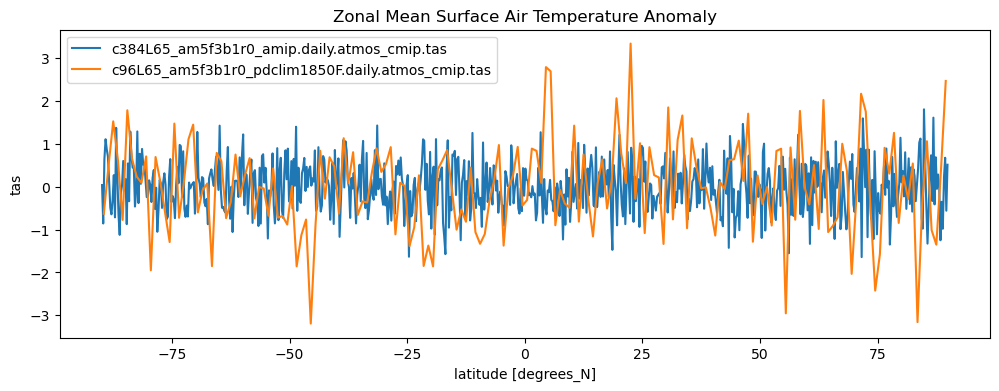

In [14]:

# Part 3: Make a plot that contains results from each case
# --------------------------------------------------------
print("Let's plot!")
print("--------------------------------------")

# set up the figure
fig = plt.figure(figsize=(12, 4))
ax = plt.subplot(1, 1, 1)

# loop over cases
for k, v in tas_arrays.items():
    v.plot(ax=ax, label=k)

# add legend
plt.legend()

# add title
plt.title("Zonal Mean Surface Air Temperature Anomaly")


In [15]:
plt.show()

## Save the plots in work directory 

In [16]:
from pathlib import Path

# save the plot in the right location
work_dir = os.environ["WORK_DIR"]
#assert os.path.isdir(f"{work_dir}/model/PS"), f'Assertion error: {work_dir}/model/PS not found'
assert os.path.isdir(work_dir), f'Assertion error: {work_dir} not found'
save_dir = Path(f"{work_dir}/model/PS")
save_dir.mkdir(parents=True, exist_ok=True)

#plt.savefig(f"{work_dir}/model/PS/example_model_plot.eps", bbox_inches="tight")
plt.savefig(f"{work_dir}/model/PS/example_model_plot.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [17]:
# Part 4: Close the catalog files and
# release variable dict reference for garbage collection
# ------------------------------------------------------
cat.close()
tas_dict = None

In [18]:
# Part 5: Confirm POD executed successfully
# ----------------------------------------
print("Last log message by example_multicase POD: finished successfully!")
sys.exit(0)

Last log message by example_multicase POD: finished successfully!


SystemExit: 0